In [1]:
import ML_Multifactor as ml
import pandas as pd


**🛠 Parameterdefinition:**
Alle Modell- und Backtestparameter sind in der Klasse `Params` definiert.

In [2]:
data = ml.Data(params)
data.get_data()
data.get_descriptive_stats()

Data wird geladen...
Data geladen.


In [3]:
# 4. Basisinfos
data.descriptive_stats['basic_info']

{'start_date': Timestamp('2006-01-02 00:00:00'),
 'end_date': Timestamp('2025-03-20 00:00:00'),
 'num_days': 5013,
 'num_assets': 594}

In [4]:
data.descriptive_stats['availability_stats']

{'min_missing_pct': 0.01994813484939158,
 'mean_missing_pct': 29.861417553418352,
 'max_missing_pct': 99.7606223818073,
 'num_fully_available_assets': 0}

In [5]:
data.descriptive_stats['return_stats'].head()

,mean,std,min,max
ABT UN Equity,0.142821,0.228112,-0.103486,0.105558
AMD UW Equity,0.102870,0.556604,-0.241179,0.257580
APD UN Equity,0.141343,0.266264,-0.149494,0.154491
HON UW Equity,0.141046,0.253143,-0.105319,0.146740
HWM UN Equity,0.143671,0.422682,-0.205047,0.259223


<Axes: title={'center': 'Anzahl verfügbarer Aktien pro Tag'}, xlabel='POS_DATE', ylabel='Aktienanzahl'>

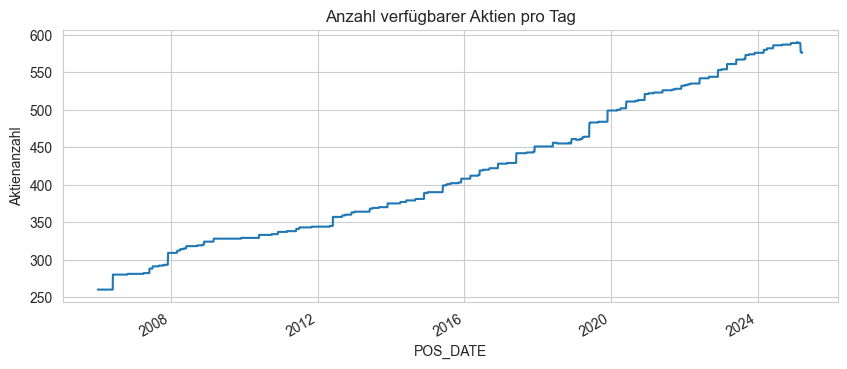

In [6]:
data.descriptive_stats['daily_availability'].plot(
    figsize=(10, 4),
    title="Anzahl verfügbarer Aktien pro Tag",
    ylabel="Aktienanzahl")

**📥 Daten:**
Es werden Kursdaten, Index-Gewichte, risikofreie Zinsen (10Y US Treasury) und der VIX geladen.


In [7]:
factors = ml.StockScores(data, params)
factors.get_factor_scores()

Factor Ränge werden berechnet...


100%|██████████| 5013/5013 [00:13<00:00, 381.52it/s]


Factor Ränge berechnet.


**📈 Faktorsignale:**
- 12-Monats-Performance (Momentum)
- 12-Monats-Volatilität (Low Volatility)
- Berechnung von Quintils-Ranks zur späteren Gewichtung


Model wird trainiert...


100%|██████████| 218/218 [00:02<00:00, 79.89it/s]


ML-Modell gespeichert.
Model trainiert.


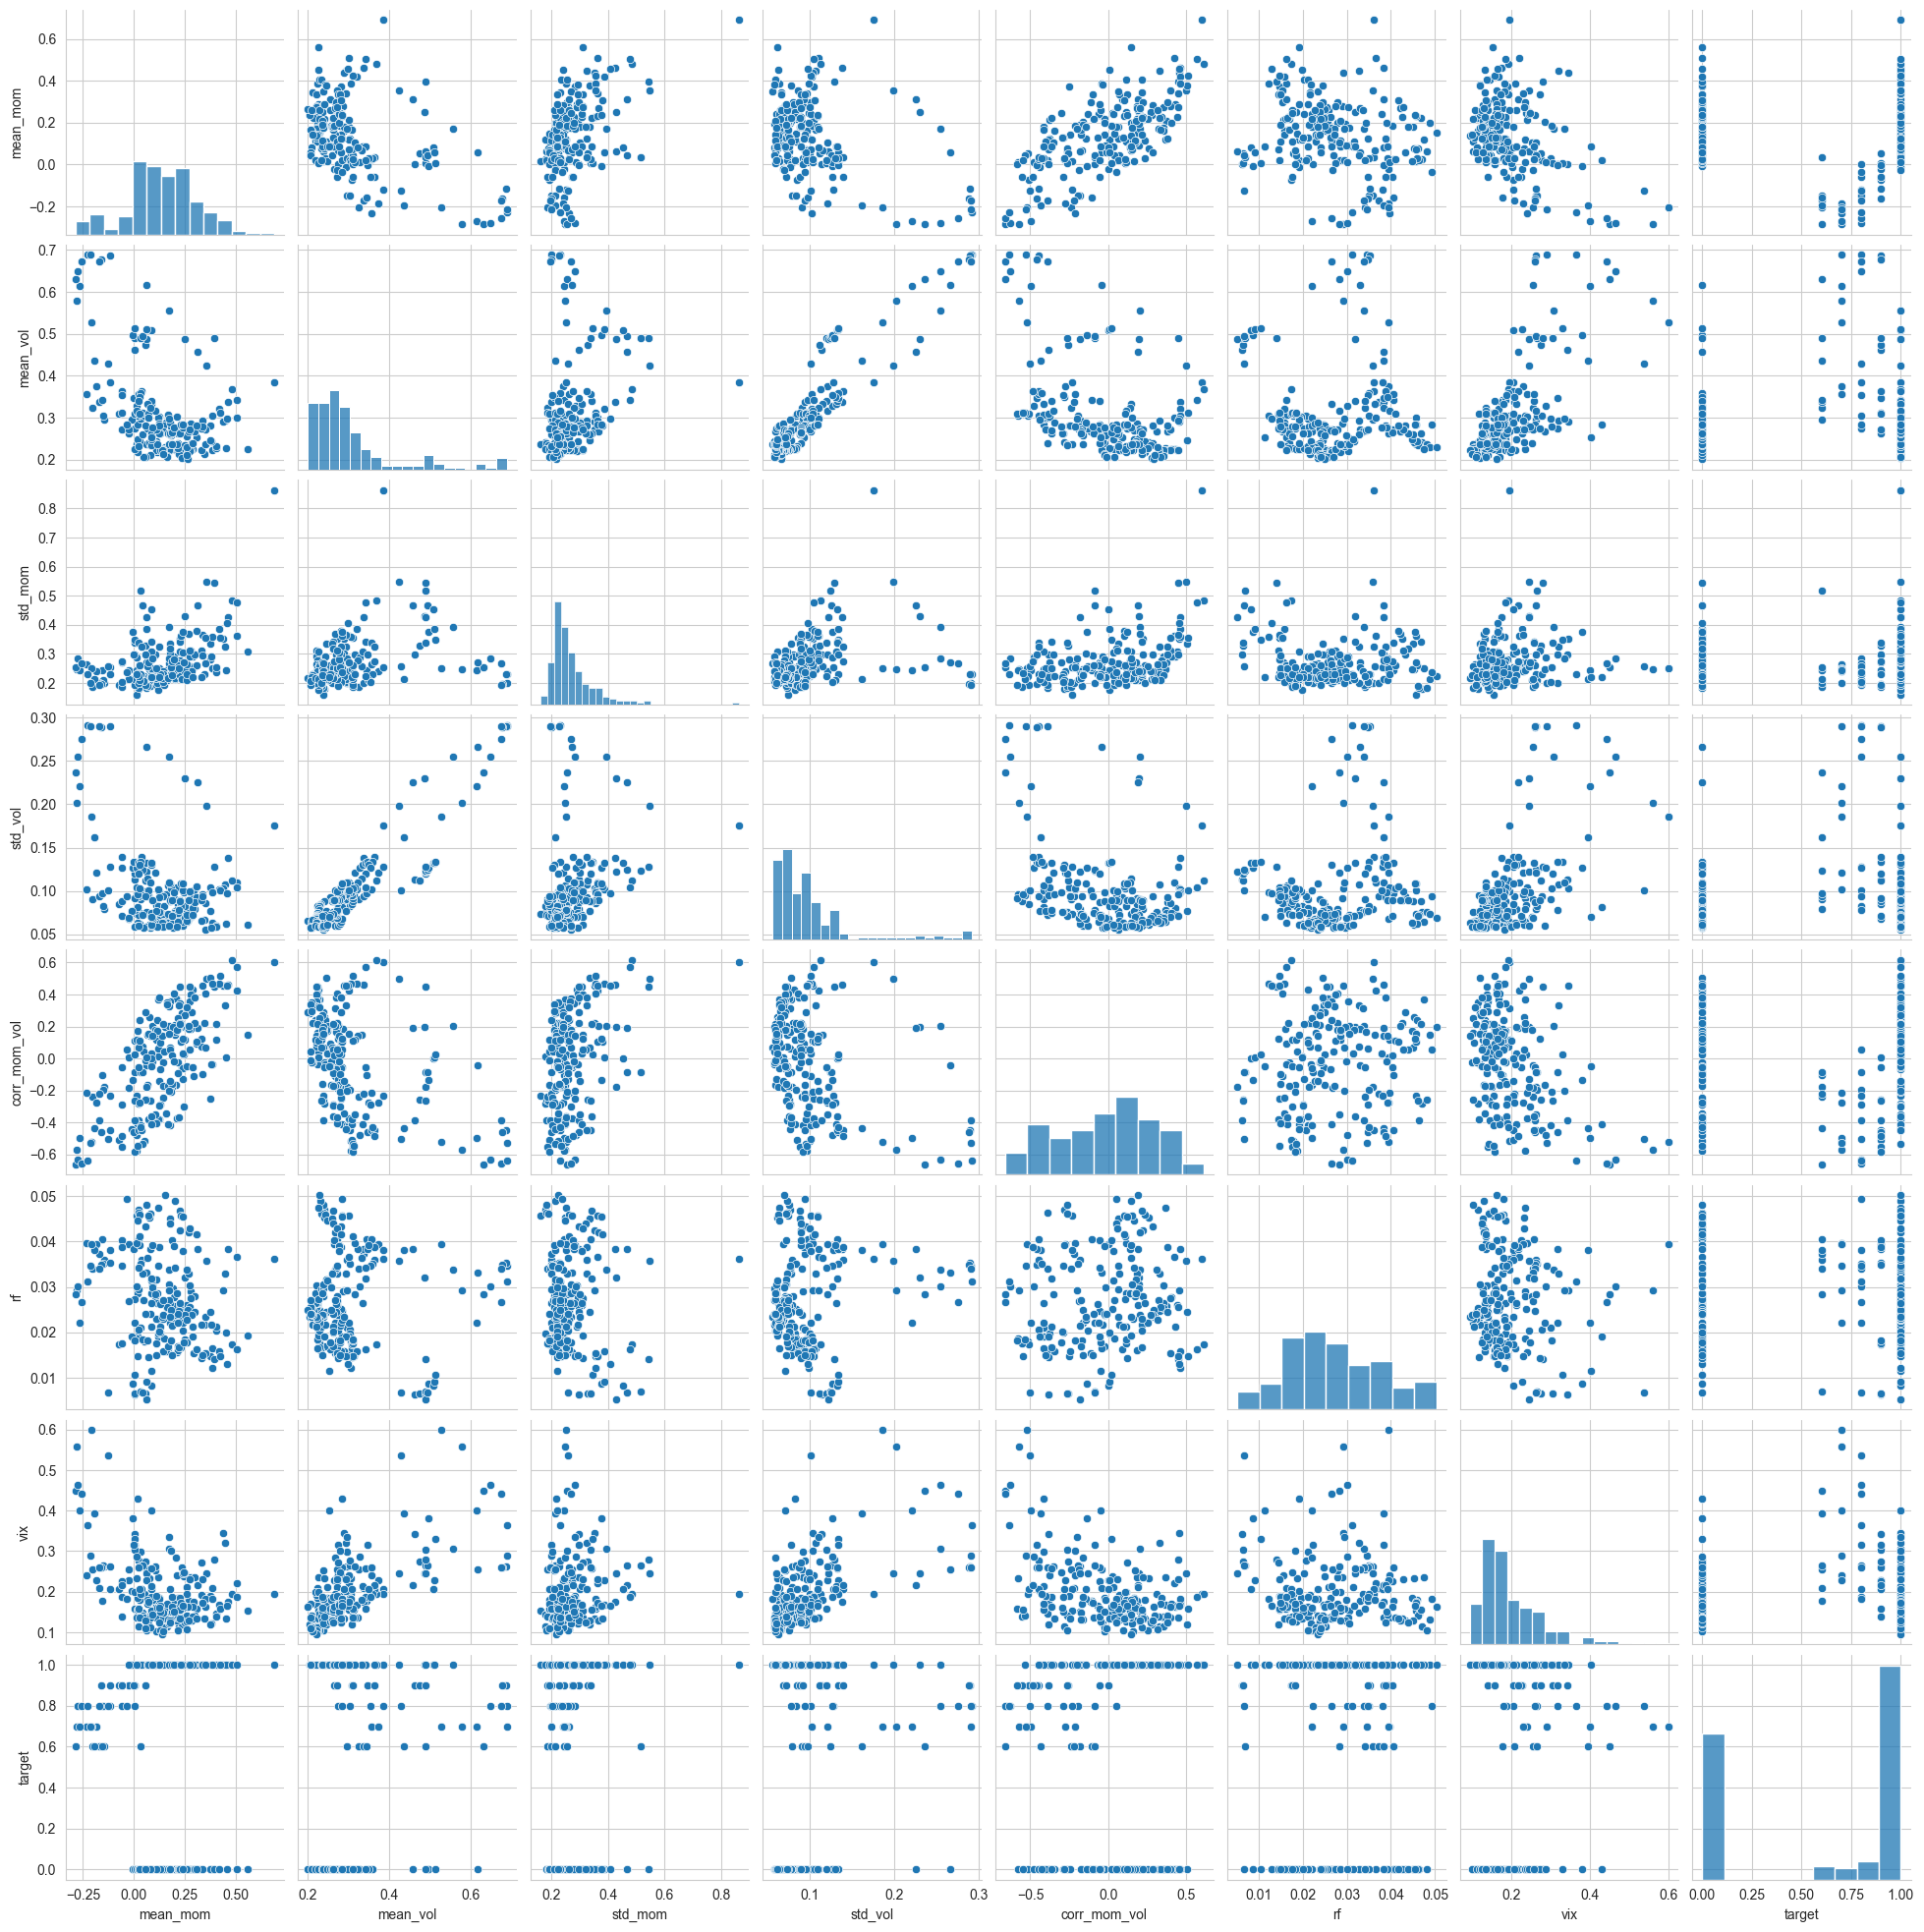

In [8]:
ml_model = ml.TrainMLModel(factors, data, params)
ml_model.train_model()

**🧠 RandomForest-Modell zur Faktorgewicht-Bestimmung:**
- Target: optimale Gewichtung von Momentum vs. Volatilität
- Features: Mittelwert, Standardabweichung, Korrelation, Zinsen, VIX


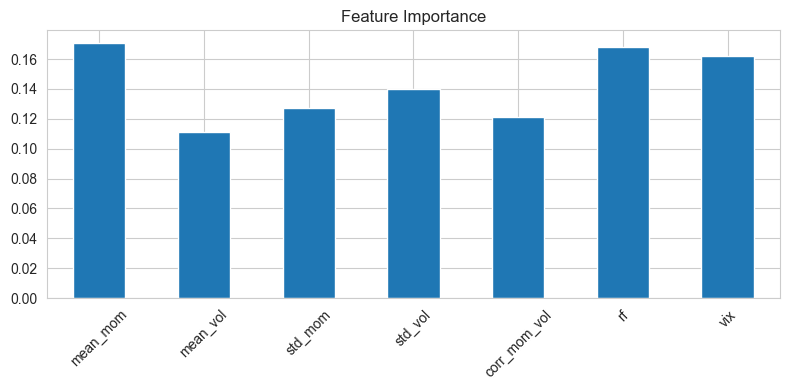

In [9]:
ml_model.df_importance.plot(kind="bar", legend=False, title="Feature Importance", figsize=(8, 4))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
ml_model.feature_stats


,F-Score,p-Value
mean_mom,0.530579,0.467153
mean_vol,1.266456,0.261682
std_mom,0.047358,0.827932
std_vol,0.768745,0.381580
corr_mom_vol,0.012019,0.912805
rf,1.914404,0.167903
vix,2.799235,0.095757


**🔍 Feature Analyse:**
Die Bedeutung einzelner Features für die ML-basierte Gewichtung wird per `feature_importances_` sowie F-Score/P-Value gezeigt.


In [11]:
factors.get_factor_weight()
factors.get_stock_weights()

backtest = ml.Backtest(data, factors, params)
backtest.run_backtest()


ML factor model wird angewendet, um Gewichte zu erhalten...


100%|██████████| 4761/4761 [00:41<00:00, 113.94it/s]


ML Factor angewendet.
Stock Weights werden aus Faktogewichten berechnet...
Stock Weights berechnet.
Backtest wird gestartet...


100%|██████████| 219/219 [00:01<00:00, 150.07it/s]

Backtest abgeschlossen.


In [12]:
backtest.bt_performance.style.background_gradient(cmap="YlGnBu")

,Average Return,Volatility,Sharpe Ratio,Max Drawdown
ML,0.142014,0.200371,0.708753,-0.434999
5050,0.138714,0.197968,0.700689,-0.431093
AVG_ML,0.139523,0.199417,0.699654,-0.433581


C:\Users\v011836\AppData\Local\Temp\ipykernel_29048\3988089369.py:4: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\PROD_VENV\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


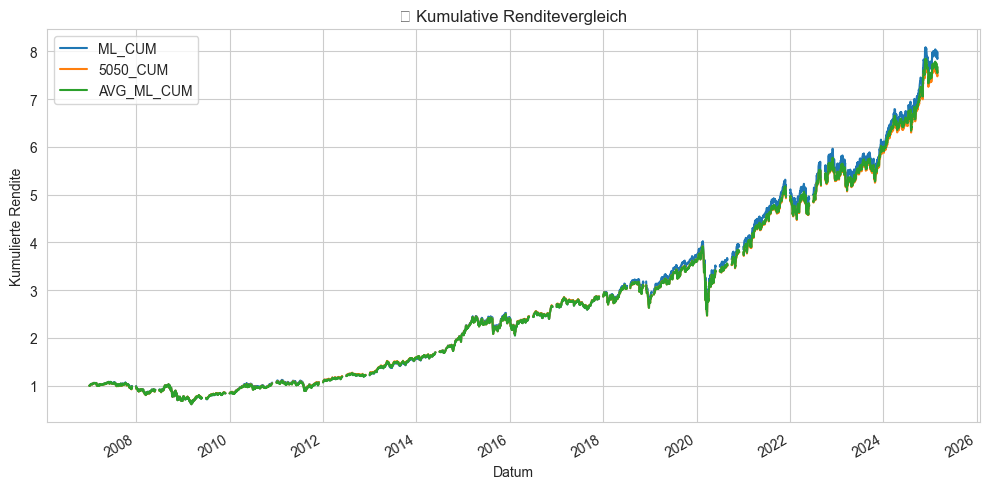

In [13]:
backtest.df_portfolio_returns[["ML_CUM", "5050_CUM", "AVG_ML_CUM"]].plot(figsize=(10, 5), title="📈 Kumulative Renditevergleich")
plt.ylabel("Kumulierte Rendite")
plt.xlabel("Datum")
plt.tight_layout()
plt.show()

In [14]:
ml.export_notebook_to_html()

🚀 Exportiere Notebook nach HTML...
✅ Export erfolgreich: G:/TEC101/ALLE/Zink/40_CPF Program/Final Project Output/Final Project Results_2025-04-01_10-28-10.html
